# PARA — VLM persona results analysis

**Dataset.** ~808k (image, annotator) aesthetic ratings; each annotator carries demographics + a Big-Five personality profile. 9 axes. Scale: 1-5 in 0.5 steps.

**What this notebook compares.** The same real raters were replayed as VLM personas under three model-side conditions, each scored against every rater's *true* value:

| condition | directory | what it is |
|---|---|---|
| `persona · T=0` | `data/logs_t_0` | each real rater role-played, greedy decoding |
| `persona · T=0.7` | `data/logs_t_0.7` | same, temperature 0.7 requested |
| `blind · T=0.7` | `data/logs_blind` | one generic rater-agnostic prompt for every image (control) |

It asks four things: (1) do persona VLMs reproduce real ratings better than predict-the-mean baselines, (2) are they biased, (3) do they reproduce each image's *distribution* of human scores, and (4) does conditioning on *who* is rating add any rater-level signal over the blind control.

In [1]:
import glob
import json
import os
from itertools import combinations

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

# --- palette: validated categorical slots (blue / aqua / amber) + chart chrome ---------
BLUE, AQUA, AMBER = "#2a78d6", "#1baf7a", "#d98a1f"
INK, SECONDARY, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
HUMAN_FILL = "#d9d7cd"                 # neutral reference fill for the real-rating histograms
GOOD, CRITICAL = "#0ca30c", "#d03b3b"
CORR_CMAP = LinearSegmentedColormap.from_list("red_gray_blue", ["#e34948", "#f0efec", "#2a78d6"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.labelcolor": SECONDARY, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.labelsize": 10, "legend.fontsize": 9, "legend.frameon": False,
    "figure.dpi": 110, "lines.linewidth": 2, "font.size": 10,
})
pd.set_option("display.width", 170, "display.max_columns", 60, "display.float_format", lambda v: f"{v:.3f}")

In [2]:
# ---- dataset configuration (the only cell that differs between the three notebooks) ----
DATASET = "PARA"
STEM_FULL, STEM_BLIND = "para_full", "para_blind"
PRIMARY_DIM = "aestheticScore"          # axis used for the headline per-image scatter
SCALE_LABEL = "1-5 in 0.5 steps"
RATER_WORD  = "annotator"

# label -> (log directory, filename stem).  Order fixes plotting order & colour slots.
CONDITIONS = {
    "persona · T=0":   ("../data/logs_t_0",   STEM_FULL),
    "persona · T=0.7": ("../data/logs_t_0.7", STEM_FULL),
    "blind · T=0.7":   ("../data/logs_blind", STEM_BLIND),
}
COND_COLOR = {"persona · T=0": BLUE, "persona · T=0.7": AQUA, "blind · T=0.7": AMBER}
print(f"{DATASET}: {len(CONDITIONS)} conditions ->", ", ".join(CONDITIONS))

PARA: 3 conditions -> persona · T=0, persona · T=0.7, blind · T=0.7


## Load the three conditions

Raw `(image, rater)` records live in the `*.part-*.json` chunks referenced by each shard manifest; per-rating metrics are recomputed here from the pooled raw records, while per-image EMD/KS and the human bootstrap floor are read from the precomputed `metrics` block (each image sits in exactly one shard, so they concatenate cleanly).

In [3]:
def _main_shards(dirp, stem):
    # the merged per-shard manifests, e.g. para_full.shard0of4.json -- NOT the .part-*.json chunks
    fs = sorted(glob.glob(os.path.join(dirp, f"{stem}.shard*of*.json")))
    return [f for f in fs if ".part-" not in f]


def load_condition(dirp, stem):
    """One condition -> raw ratings (wide df), pooled per-image table, config, axis grids.

    The manifest holds config + precomputed metrics + a list of result_parts; the raw
    (image, rater) records live in those .part-*.json files. Images never span shards
    (stratified by image), so per-image rows from every shard simply concatenate.
    """
    shards = _main_shards(dirp, stem)
    if not shards:
        raise FileNotFoundError(f"no shards matched {stem} under {dirp}")
    recs, per_image, grids, cfg = [], [], {}, None
    for mf in shards:
        d = json.load(open(mf))
        cfg = d  # config is identical across a condition's shards apart from the `shard` field
        for dim, dm in d["metrics"]["per_dimension"].items():
            grids.setdefault(dim, dm["distribution"]["score_grid"])
            per_image.extend({**row, "dim": dim} for row in dm["per_image"])
        for part in d["result_parts"]:
            for r in json.load(open(os.path.join(dirp, part))):
                recs.append({k: v for k, v in r.items() if k not in ("comment", "raw_response")})
    dims = [x["name"] if isinstance(x, dict) else x for x in cfg["dimensions"]]
    df = pd.DataFrame(recs)
    for dim in dims:                       # coerce so unparsed (None) predictions become NaN
        for pfx in ("gt_", "pred_"):
            df[pfx + dim] = pd.to_numeric(df[pfx + dim], errors="coerce")
    return dict(df=df, pimg=pd.DataFrame(per_image), cfg=cfg, dims=dims,
                grids=grids, n_shards=len(shards))


DATA = {label: load_condition(dirp, stem) for label, (dirp, stem) in CONDITIONS.items()}
DIMS = DATA["persona · T=0"]["dims"]
GRIDS = DATA["persona · T=0"]["grids"]
for lbl, d in DATA.items():               # every condition must share the same axes to be comparable
    assert d["dims"] == DIMS, f"{lbl} has different dimensions: {d['dims']}"

PERSONA_CONDS = [l for l, d in DATA.items() if not d["cfg"].get("persona_blind")]
BLIND_CONDS   = [l for l, d in DATA.items() if d["cfg"].get("persona_blind")]
print("axes:", ", ".join(DIMS))
print("persona conditions:", PERSONA_CONDS, "| blind:", BLIND_CONDS)

axes: aestheticScore, qualityScore, compositionScore, colorScore, dofScore, contentScore, lightScore, contentPreference, willingnessToShare
persona conditions: ['persona · T=0', 'persona · T=0.7'] | blind: ['blind · T=0.7']


In [4]:
def overall_parse_rate(df, dims):
    cells = len(df) * len(dims)
    got = int(sum(df[f"pred_{d}"].notna().sum() for d in dims))
    return got / cells if cells else float("nan")

meta = pd.DataFrame({
    lbl: {
        "temperature": d["cfg"].get("temperature"),
        "top_k": d["cfg"].get("top_k"), "top_p": d["cfg"].get("top_p"),
        "persona_blind": d["cfg"].get("persona_blind"),
        "sampling": d["cfg"].get("sampling"), "seed": d["cfg"].get("seed"),
        "shards": d["n_shards"],
        "images": d["df"]["imageName"].nunique(),
        "raters": d["df"]["userId"].nunique(),
        "ratings": len(d["df"]),
        "parse_rate": round(overall_parse_rate(d["df"], DIMS), 4),
        "generated_at": d["cfg"].get("generated_at", "")[:19],
    }
    for lbl, d in DATA.items()
}).T
meta

,temperature,top_k,top_p,persona_blind,sampling,seed,shards,images,raters,ratings,parse_rate,generated_at
persona · T=0,0.000,None,None,None,stratified,0,4,2000,437,51749,1.000,2026-07-06T19:38:28
persona · T=0.7,0.700,None,None,False,stratified,0,8,4000,438,103477,1.000,2026-07-14T13:27:37
blind · T=0.7,0.700,None,None,True,stratified,0,4,2000,437,51749,1.000,2026-07-08T15:43:44


In [5]:
# Persona vs blind must use different prompts, or the "blind" control is not a control.
p_lbl, b_lbl = PERSONA_CONDS[0], BLIND_CONDS[0]
p_cfg, b_cfg = DATA[p_lbl]["cfg"], DATA[b_lbl]["cfg"]
print(f"persona system prompt == blind system prompt ?  "
      f"{p_cfg['system_prompt_template'] == b_cfg['system_prompt_template']}")
print(f"persona question      == blind question      ?  {p_cfg['question'] == b_cfg['question']}\n")
print("--- persona system prompt (template) ---\n" + p_cfg["system_prompt_template"][:600])
print("\n--- blind system prompt ---\n" + b_cfg["system_prompt_template"][:600])
print("\n--- blind question ---\n" + b_cfg["question"][:400])

persona system prompt == blind system prompt ?  False
persona question      == blind question      ?  False

--- persona system prompt (template) ---
You are role-playing as one specific human annotator from a photo-aesthetics rating study. The annotator is {description}

You are shown one photograph from the study. Judge it the way this exact person would: let their age, gender, education, art and photography experience, and Big-Five personality shape both what they notice and how critical or generous they are. Not every photo deserves a good score; be honest when a photo would bore or disappoint this person. Do not mention that you are an AI or that you are role-playing.

--- blind system prompt ---
You are an impartial, general-purpose judge of photographic aesthetics.

You are shown one photograph from a photo-aesthetics rating study. Judge it on its own merits the way a typical viewer would, without adopting any particular person's perspective or taste. Not every photo deserves a 

> ### ⚠️ Two caveats baked into these runs (from `CLAUDE.md`)
> 1. **Temperature did nothing.** `Qwen2-VL` ships `top_k=1, top_p=0.001`, and none of these para/eva/lapis runs override it, so decoding stayed **greedy even at T=0.7**. Treat `persona · T=0.7` as a second greedy run on a different image sample, not a sampling condition.
> 2. **Blind distribution metrics are invalid.** Because decoding is greedy and the blind prompt is identical across an image's raters, every rater gets a byte-identical answer → ~zero within-image spread. Blind **point** metrics (MAE/RMSE/bias/correlation) are fine; blind **EMD/KS/within-image** numbers are not, and are flagged where they appear.

## Shared analysis helpers

Rating-level metrics, per-image and within-image correlations, and grid-aware histograms — all operating on the wide raw frames.

In [6]:
def pairs(df, dim):
    # tidy (image, ground-truth, prediction) with unparsed predictions dropped
    s = df[["imageName", f"gt_{dim}", f"pred_{dim}"]].rename(
        columns={f"gt_{dim}": "gt", f"pred_{dim}": "pred"})
    return s.dropna()


def per_rating_metrics(df, dim):
    # rating-level agreement + the two persona-blind statistical baselines (predict a mean)
    p = pairs(df, dim)
    gt, pr = p["gt"].to_numpy(), p["pred"].to_numpy()
    err = pr - gt
    img_mean = p.groupby("imageName")["gt"].transform("mean").to_numpy()
    ok = pr.std() > 0 and gt.std() > 0
    return dict(
        n=len(p),
        mae=np.abs(err).mean(), rmse=np.sqrt((err ** 2).mean()), bias=err.mean(),
        pearson=stats.pearsonr(pr, gt)[0] if ok else np.nan,
        spearman=stats.spearmanr(pr, gt)[0] if ok else np.nan,
        base_mae_global=np.abs(gt - gt.mean()).mean(),   # predict one global mean for every rating
        base_mae_image=np.abs(gt - img_mean).mean(),     # predict each image's own human mean
        human_sd=gt.std(),
    )


def image_mean_corr(df, dim):
    # how well the model orders images (per-image mean prediction vs per-image human mean)
    g = pairs(df, dim).groupby("imageName").agg(h=("gt", "mean"), v=("pred", "mean"))
    if len(g) < 3 or g["v"].std() == 0:
        return np.nan
    return stats.pearsonr(g["v"], g["h"])[0]


def within_image_corr(df, dim, min_n=3):
    # for a FIXED image, does the model track which raters scored it higher? (rater-level signal)
    rs, n_pred_varies, n_img = [], 0, 0
    for _, g in pairs(df, dim).groupby("imageName"):
        if len(g) < min_n:
            continue
        n_img += 1
        pv = g["pred"].std() > 0
        n_pred_varies += pv
        if pv and g["gt"].std() > 0:
            r = stats.pearsonr(g["pred"], g["gt"])[0]
            if np.isfinite(r):
                rs.append(r)
    return dict(mean_r=np.mean(rs) if rs else np.nan, n_scored=len(rs),
                frac_pred_varies=(n_pred_varies / n_img) if n_img else np.nan, n_img=n_img)


def hist_on_grid(vals, grid):
    # normalised histogram; snap to the axis grid, but coarsen very fine grids (e.g. 0-100)
    grid = np.asarray(grid, float)
    vals = np.asarray(vals, float)
    if len(grid) > 25:
        edges = np.linspace(grid[0], grid[-1], 26)
        centers = 0.5 * (edges[:-1] + edges[1:])
    else:
        step = np.median(np.diff(grid)) if len(grid) > 1 else 1.0
        edges = np.concatenate([grid - step / 2, [grid[-1] + step / 2]])
        centers = grid
    h, _ = np.histogram(vals, bins=edges)
    tot = h.sum()
    return centers, (h / tot if tot else h), float(np.median(np.diff(centers)) if len(centers) > 1 else 1.0)


def grid_shape(n):
    ncol = 1 if n == 1 else (2 if n <= 4 else 3)
    return int(np.ceil(n / ncol)), ncol

## 1 · Agreement with real ratings

The core question. `base_mae_image` = predict each image's own human mean; `base_mae_global` = predict one global mean. Beating `base_mae_image` is the bar that matters — it is what the model must clear to be worth more than a lookup table of image averages.

In [7]:
# rating-level metrics for every (condition, axis); baselines are ground-truth-only so
# they are reported once (from the persona-T=0 task set, which the blind run shares exactly).
rows = []
for lbl, d in DATA.items():
    for dim in DIMS:
        m = per_rating_metrics(d["df"], dim)
        rows.append(dict(condition=lbl, axis=dim, n=m["n"], mae=m["mae"], rmse=m["rmse"],
                         bias=m["bias"], pearson=m["pearson"], spearman=m["spearman"],
                         base_mae_image=m["base_mae_image"], base_mae_global=m["base_mae_global"],
                         mae_vs_imagebase=m["mae"] / m["base_mae_image"]))
agree = pd.DataFrame(rows)
print("Rating-level agreement.  mae_vs_imagebase < 1  ==  beats 'predict the image's human mean'.\n")
agree.set_index(["axis", "condition"]).sort_index()

Rating-level agreement.  mae_vs_imagebase < 1  ==  beats 'predict the image's human mean'.



n   mae  rmse  bias  pearson  spearman  base_mae_image  base_mae_global  mae_vs_imagebase
axis               condition                                                                                                      
aestheticScore     blind · T=0.7     51749 0.639 0.834 0.276    0.587     0.533           0.438            0.611             1.459
                   persona · T=0     51734 0.828 1.025 0.648    0.554     0.493           0.438            0.611             1.891
                   persona · T=0.7  103477 0.820 1.022 0.630    0.558     0.496           0.439            0.611             1.868
colorScore         blind · T=0.7     51749 0.964 1.261 0.669    0.423     0.403           0.614            0.659             1.571
                   persona · T=0     51734 1.277 1.556 1.105    0.411     0.389           0.614            0.659             2.081
                   persona · T=0.7  103477 1.253 1.538 1.093    0.414     0.391           0.615            0.663             2.038
compositionScore   blind · T=0.7     51749 0.728 1.001 0.367    0.420     0.377           0.538            0.658             1.354
                   persona · T=0     51734 0.741 1.011 0.394    0.419     0.376           0.538            0.658             1.379
                   persona · T=0.7  103477 0.755 1.025 0.447    0.424     0.377           0.537            0.659             1.405
contentPreference  blind · T=0.7     51749 0.826 1.111 0.461    0.429     0.402           0.576            0.724             1.435
                   persona · T=0     51734 0.957 1.245 0.643    0.395     0.364           0.576            0.724             1.663
                   persona · T=0.7  103477 0.942 1.230 0.649    0.398     0.364           0.574            0.723             1.643
contentScore       blind · T=0.7     51749 0.825 1.122 0.520    0.412     0.377           0.543            0.554             1.518
                   persona · T=0     51734 0.967 1.275 0.632    0.390     0.360           0.543            0.554             1.780
                   persona · T=0.7  103477 0.944 1.249 0.640    0.396     0.363           0.544            0.555             1.736
dofScore           blind · T=0.7     51749 0.933 1.205 0.663    0.441     0.390           0.571            0.686             1.635
                   persona · T=0     51734 1.157 1.425 0.976    0.413     0.341           0.571            0.686             2.027
                   persona · T=0.7  103477 1.168 1.434 1.000    0.425     0.361           0.574            0.688             2.037
lightScore         blind · T=0.7     51749 0.972 1.265 0.678    0.445     0.410           0.661            0.760             1.471
                   persona · T=0     51734 1.342 1.621 1.209    0.436     0.396           0.661            0.760             2.030
                   persona · T=0.7  103477 1.318 1.602 1.183    0.437     0.397           0.662            0.760             1.992
qualityScore       blind · T=0.7     51749 0.826 0.990 0.584    0.610     0.518           0.429            0.600             1.925
                   persona · T=0     51734 0.991 1.155 0.857    0.600     0.502           0.429            0.600             2.311
                   persona · T=0.7  103477 1.006 1.169 0.876    0.601     0.505           0.430            0.601             2.338
willingnessToShare blind · T=0.7     51749 0.920 1.222 0.595    0.436     0.416           0.660            0.798             1.394
                   persona · T=0     51734 1.060 1.373 0.730    0.406     0.381           0.660            0.798             1.605
                   persona · T=0.7  103477 1.023 1.335 0.722    0.406     0.378           0.661            0.798             1.549

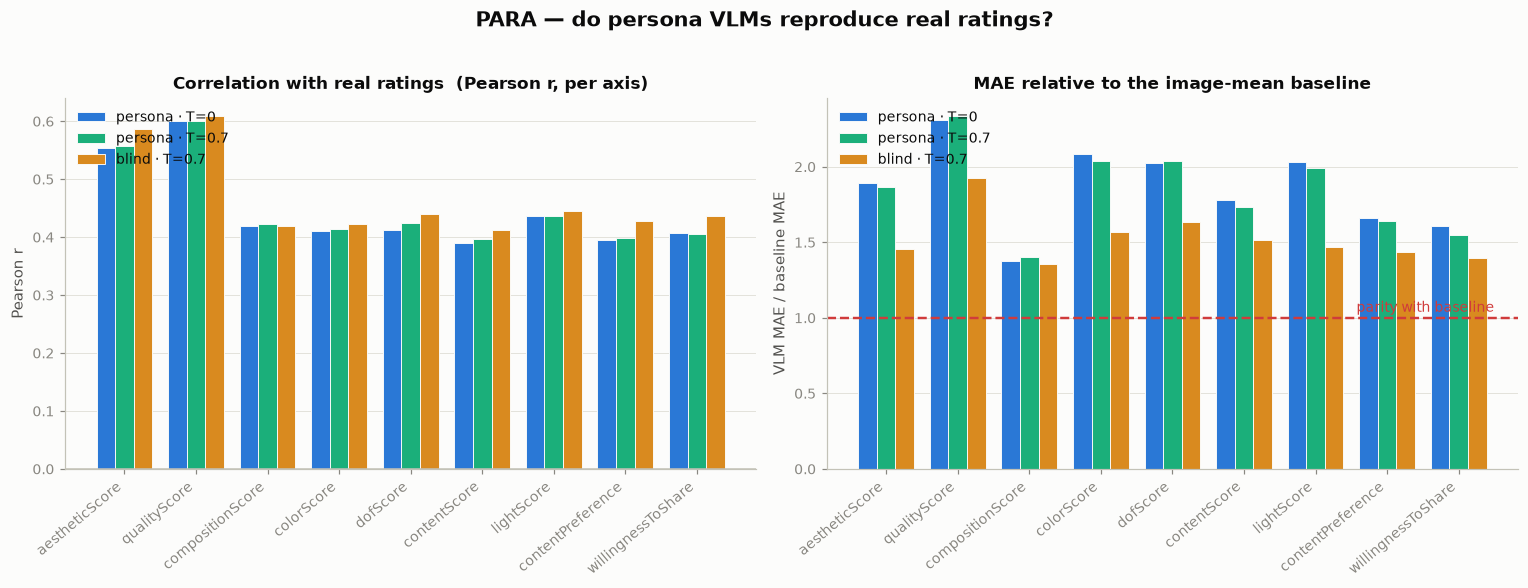

In [8]:
# Two scale-free headline views: correlation (higher=better) and MAE relative to the
# image-mean baseline (below the red line = the model actually beats the naive baseline).
x = np.arange(len(DIMS)); w = 0.26
fig, (axc, axr) = plt.subplots(1, 2, figsize=(14, 5.2))
for i, lbl in enumerate(DATA):
    pe = [per_rating_metrics(DATA[lbl]["df"], dim)["pearson"] for dim in DIMS]
    rt = [r["mae"] / r["base_mae_image"] for r in (per_rating_metrics(DATA[lbl]["df"], dim) for dim in DIMS)]
    off = (i - 1) * w
    axc.bar(x + off, pe, w, color=COND_COLOR[lbl], label=lbl, edgecolor=SURFACE, linewidth=0.6)
    axr.bar(x + off, rt, w, color=COND_COLOR[lbl], label=lbl, edgecolor=SURFACE, linewidth=0.6)
axc.set_title("Correlation with real ratings  (Pearson r, per axis)")
axc.set_ylabel("Pearson r"); axc.axhline(0, color=BASELINE, lw=1)
axr.set_title("MAE relative to the image-mean baseline")
axr.set_ylabel("VLM MAE / baseline MAE")
axr.axhline(1.0, color=CRITICAL, lw=1.6, ls="--")
axr.annotate("parity with baseline", xy=(len(DIMS) - 0.5, 1.0), xytext=(0, 4),
             textcoords="offset points", ha="right", color=CRITICAL, fontsize=9)
for ax in (axc, axr):
    ax.set_xticks(x, DIMS, rotation=40, ha="right"); ax.xaxis.grid(False)
    ax.legend(loc="upper left", ncol=1)
fig.suptitle(f"{DATASET} — do persona VLMs reproduce real ratings?", fontsize=14,
             fontweight="bold", color=INK, y=1.02)
fig.tight_layout(); plt.show()

## 2 · Bias & score distributions

Where the model puts its scores versus where humans put theirs.

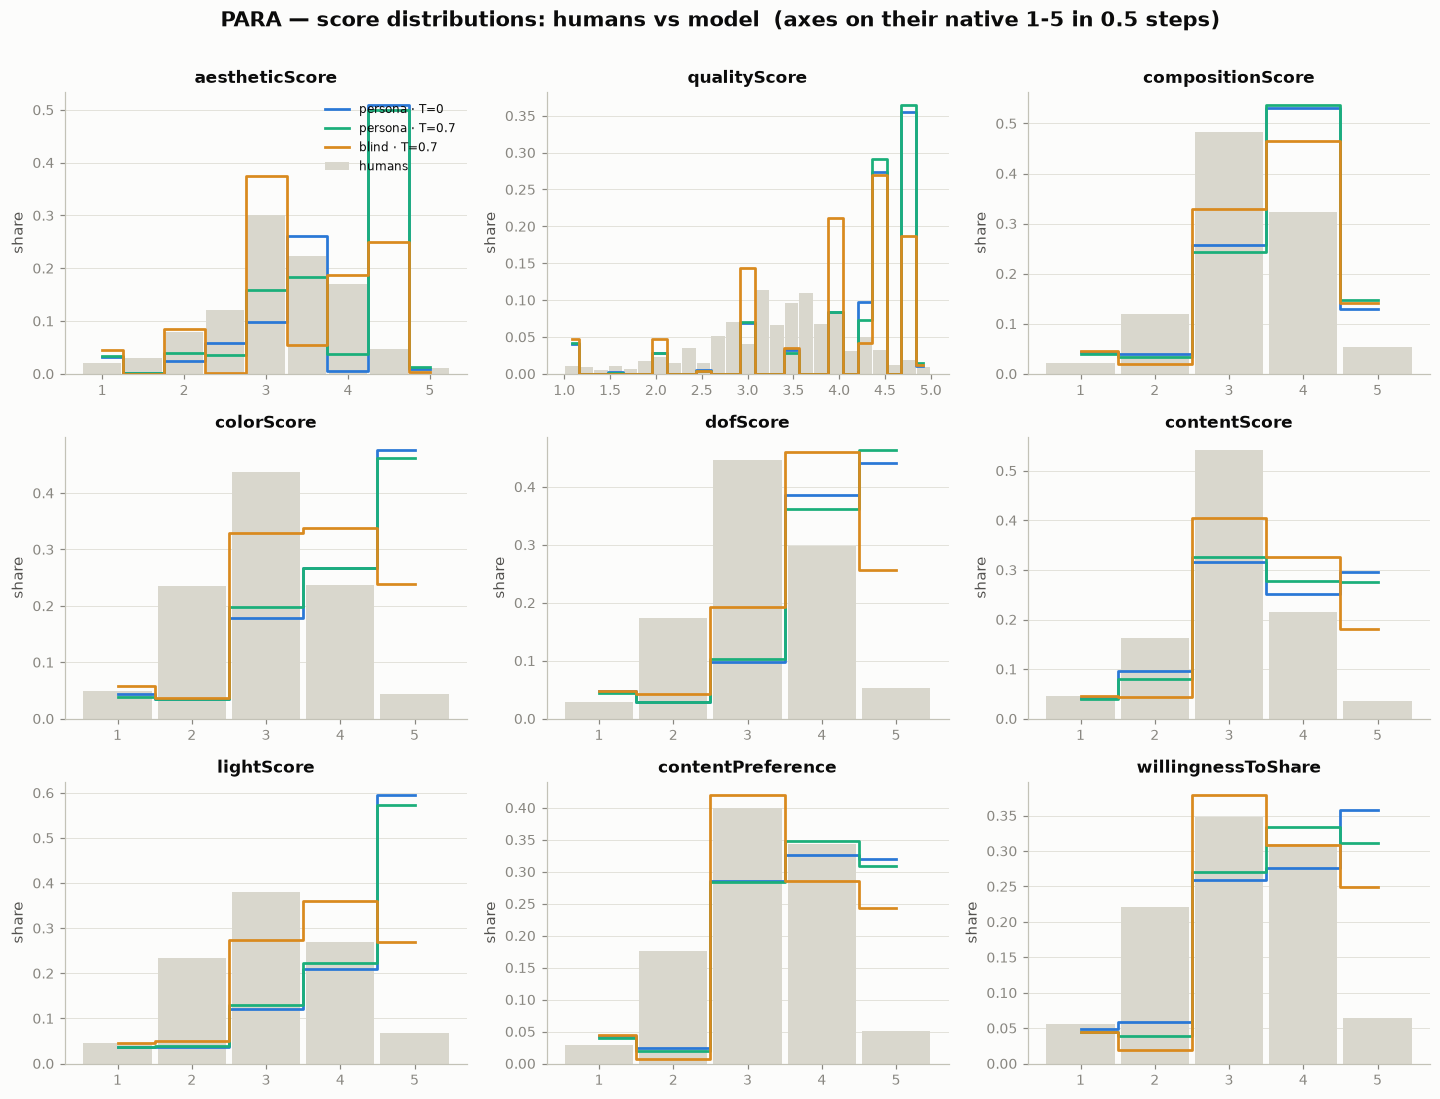

In [9]:
# Real-rating distribution (grey) vs each condition's prediction distribution, per axis.
nr, nc = grid_shape(len(DIMS))
fig, axes = plt.subplots(nr, nc, figsize=(4.4 * nc, 3.3 * nr), squeeze=False)
human_df = DATA["persona · T=0"]["df"]          # human ratings (shared with the blind task set)
for ax, dim in zip(axes.flat, DIMS):
    grid = GRIDS[dim]
    hc, hh, hw = hist_on_grid(pairs(human_df, dim)["gt"], grid)
    ax.bar(hc, hh, width=hw * 0.92, color=HUMAN_FILL, label="humans", zorder=1)
    for lbl, d in DATA.items():
        c, h, _ = hist_on_grid(pairs(d["df"], dim)["pred"], grid)
        ax.step(c, h, where="mid", color=COND_COLOR[lbl], lw=1.8, label=lbl, zorder=3)
    ax.set_title(dim); ax.xaxis.grid(False); ax.set_ylabel("share")
for ax in axes.flat[len(DIMS):]:
    ax.set_visible(False)
axes.flat[0].legend(loc="upper right", fontsize=8)
fig.suptitle(f"{DATASET} — score distributions: humans vs model  (axes on their native {SCALE_LABEL})",
             fontsize=14, fontweight="bold", color=INK, y=1.005)
fig.tight_layout(); plt.show()

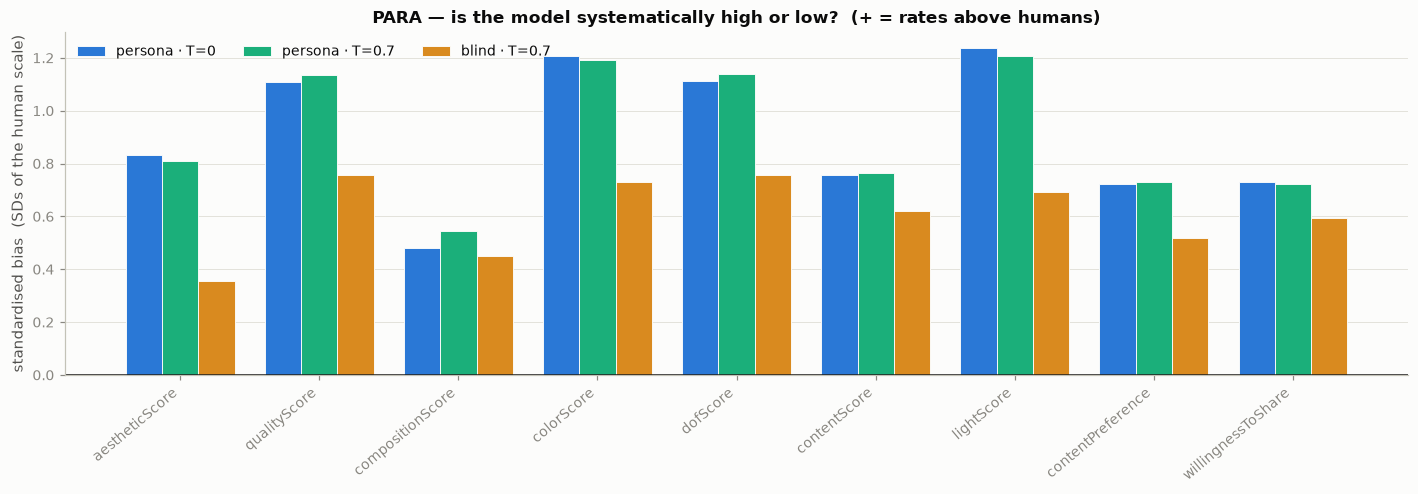

In [10]:
# Standardised mean bias = mean(pred - human) / sd(human), so axes on different scales compare.
x = np.arange(len(DIMS)); w = 0.26
fig, ax = plt.subplots(figsize=(13, 4.6))
for i, lbl in enumerate(DATA):
    sb = []
    for dim in DIMS:
        m = per_rating_metrics(DATA[lbl]["df"], dim)
        sb.append(m["bias"] / m["human_sd"] if m["human_sd"] else np.nan)
    ax.bar(x + (i - 1) * w, sb, w, color=COND_COLOR[lbl], label=lbl, edgecolor=SURFACE, linewidth=0.6)
ax.axhline(0, color=INK, lw=1)
ax.set_xticks(x, DIMS, rotation=40, ha="right"); ax.xaxis.grid(False)
ax.set_ylabel("standardised bias  (SDs of the human scale)")
ax.set_title(f"{DATASET} — is the model systematically high or low?  (+ = rates above humans)")
ax.legend(ncol=3, loc="best"); fig.tight_layout(); plt.show()

## 3 · Per-image distribution match

Beyond the mean: does the model reproduce the *spread* of scores a single image draws from its raters? Compared against a human bootstrap floor (how far a resample of the humans lands from the humans). Persona conditions only are interpretable here.

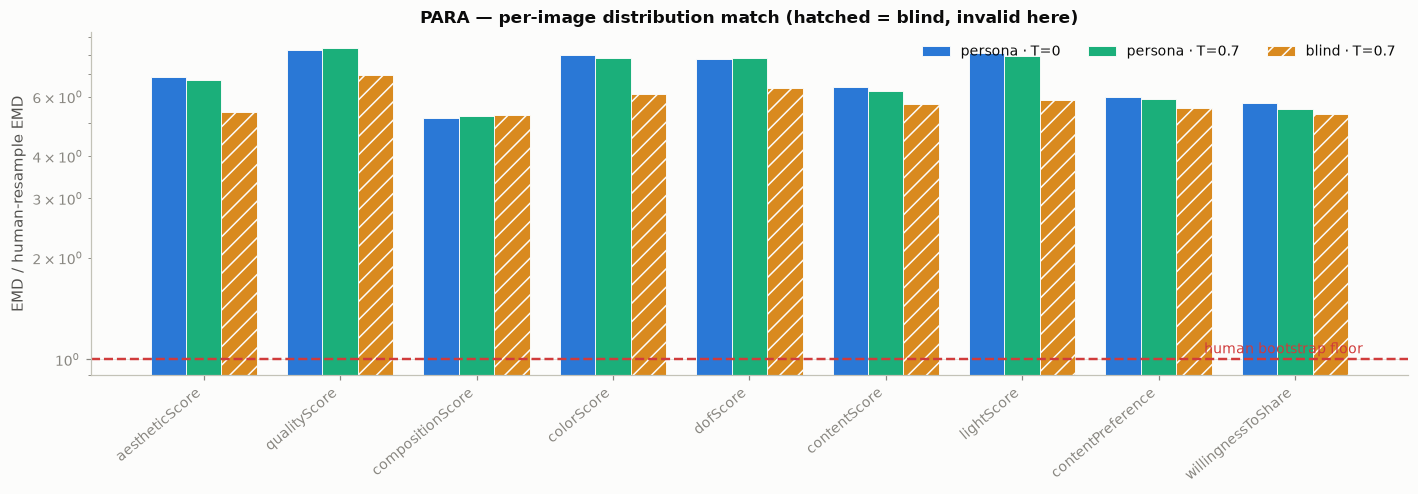

emd  human_floor  emd_ratio    ks  vlm_std  human_std
axis               condition                                                              
aestheticScore     blind · T=0.7   0.628        0.116      5.415 0.621    0.026      0.557
                   persona · T=0   0.794        0.116      6.845 0.710    0.143      0.558
                   persona · T=0.7 0.781        0.116      6.707 0.686    0.153      0.559
colorScore         blind · T=0.7   0.948        0.155      6.119 0.617    0.054      0.776
                   persona · T=0   1.238        0.155      7.982 0.718    0.198      0.776
                   persona · T=0.7 1.214        0.155      7.816 0.704    0.206      0.777
compositionScore   blind · T=0.7   0.709        0.133      5.312 0.518    0.043      0.681
                   persona · T=0   0.692        0.133      5.186 0.501    0.142      0.681
                   persona · T=0.7 0.705        0.134      5.272 0.508    0.143      0.681
contentPreference  blind · T=0.7   0.806        0.146      5.540 0.553    0.056      0.732
                   persona · T=0   0.869        0.145      5.972 0.545    0.296      0.732
                   persona · T=0.7 0.857        0.145      5.905 0.545    0.285      0.731
contentScore       blind · T=0.7   0.807        0.141      5.713 0.549    0.052      0.708
                   persona · T=0   0.907        0.141      6.414 0.555    0.250      0.708
                   persona · T=0.7 0.884        0.141      6.261 0.547    0.246      0.708
dofScore           blind · T=0.7   0.919        0.144      6.389 0.636    0.052      0.726
                   persona · T=0   1.121        0.144      7.779 0.694    0.208      0.726
                   persona · T=0.7 1.134        0.145      7.807 0.697    0.218      0.731
lightScore         blind · T=0.7   0.953        0.162      5.867 0.607    0.057      0.820
                   persona · T=0   1.311        0.162      8.071 0.740    0.172      0.820
                   persona · T=0.7 1.286        0.163      7.901 0.726    0.187      0.821
qualityScore       blind · T=0.7   0.817        0.117      6.957 0.850    0.031      0.545
                   persona · T=0   0.972        0.118      8.273 0.877    0.112      0.545
                   persona · T=0.7 0.986        0.118      8.383 0.882    0.113      0.547
willingnessToShare blind · T=0.7   0.899        0.168      5.338 0.574    0.063      0.837
                   persona · T=0   0.971        0.168      5.763 0.561    0.303      0.837
                   persona · T=0.7 0.933        0.169      5.538 0.546    0.304      0.838

In [11]:
# Per-image distribution match vs the human bootstrap floor.  emd_ratio = model EMD /
# human-resample EMD; >1 means the model's per-image spread is further from the humans than
# humans are from a resample of themselves.  Blind is shown but is invalid here (decoding
# collapse -> ~zero within-image spread; see the caveat cell).
rows = []
for lbl, d in DATA.items():
    pi = d["pimg"]
    for dim in DIMS:
        s = pi[pi["dim"] == dim]
        if s.empty:
            continue
        rows.append(dict(condition=lbl, axis=dim,
                         emd=s["emd"].mean(), human_floor=s["human_resample_emd"].mean(),
                         emd_ratio=s["emd"].mean() / s["human_resample_emd"].mean(),
                         ks=s["ks"].mean(), vlm_std=s["vlm_std"].mean(), human_std=s["human_std"].mean()))
emd = pd.DataFrame(rows)

x = np.arange(len(DIMS)); w = 0.26
fig, ax = plt.subplots(figsize=(13, 4.6))
for i, lbl in enumerate(DATA):
    sub = emd[emd["condition"] == lbl].set_index("axis").reindex(DIMS)
    ax.bar(x + (i - 1) * w, sub["emd_ratio"], w, color=COND_COLOR[lbl], label=lbl,
           edgecolor=SURFACE, linewidth=0.6, hatch="//" if lbl in BLIND_CONDS else None)
ax.axhline(1.0, color=CRITICAL, lw=1.6, ls="--")
ax.annotate("human bootstrap floor", xy=(len(DIMS) - 0.5, 1.0), xytext=(0, 4),
            textcoords="offset points", ha="right", color=CRITICAL, fontsize=9)
ax.set_xticks(x, DIMS, rotation=40, ha="right"); ax.xaxis.grid(False)
ax.set_ylabel("EMD / human-resample EMD"); ax.set_yscale("log")
ax.set_title(f"{DATASET} — per-image distribution match (hatched = blind, invalid here)")
ax.legend(ncol=3, loc="best"); fig.tight_layout(); plt.show()
emd.set_index(["axis", "condition"]).sort_index()

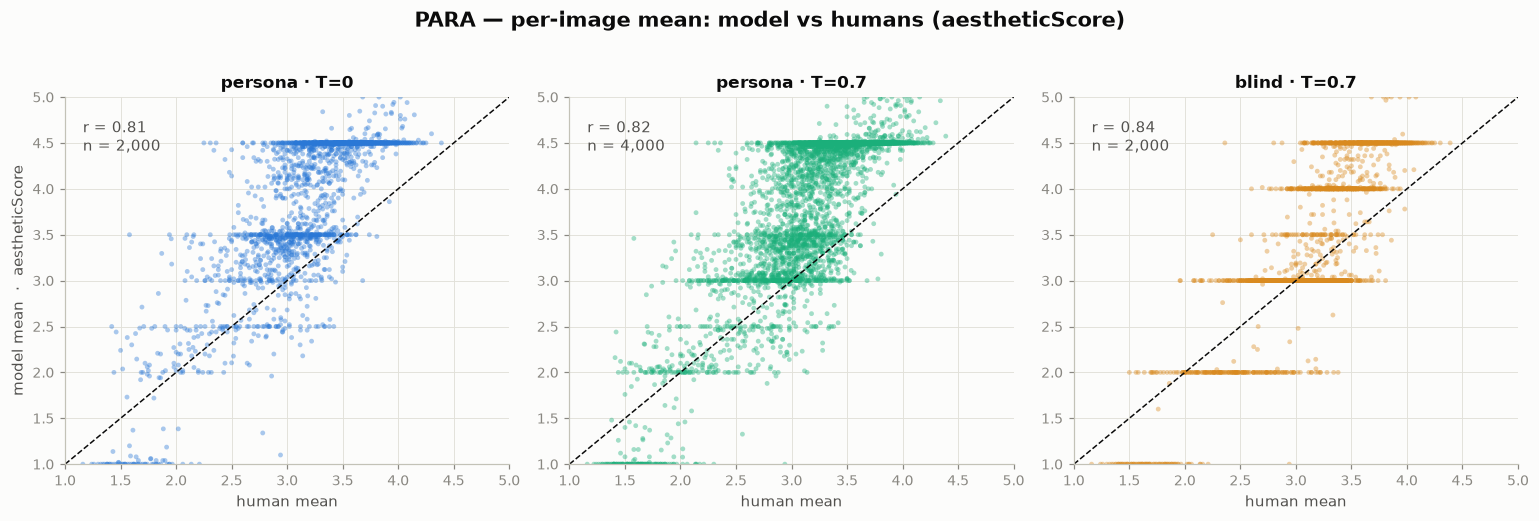

In [12]:
# Image ordering on the headline axis: each dot is one image, x=human mean, y=model mean.
fig, axes = plt.subplots(1, len(DATA), figsize=(4.7 * len(DATA), 4.6), squeeze=False)
grid = GRIDS[PRIMARY_DIM]; lo, hi = grid[0], grid[-1]
for ax, (lbl, d) in zip(axes.flat, DATA.items()):
    s = d["pimg"][d["pimg"]["dim"] == PRIMARY_DIM]
    ax.scatter(s["human_mean"], s["vlm_mean"], s=10, color=COND_COLOR[lbl], alpha=0.4,
               edgecolor="none")
    ax.plot([lo, hi], [lo, hi], color=INK, lw=1, ls="--")
    r = image_mean_corr(d["df"], PRIMARY_DIM)
    ax.annotate(f"r = {r:.2f}\nn = {len(s):,}", xy=(0.04, 0.94), xycoords="axes fraction",
                va="top", fontsize=10, color=SECONDARY)
    ax.set_title(lbl); ax.set_xlabel("human mean"); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
axes.flat[0].set_ylabel(f"model mean  ·  {PRIMARY_DIM}")
fig.suptitle(f"{DATASET} — per-image mean: model vs humans ({PRIMARY_DIM})", fontsize=14,
             fontweight="bold", color=INK, y=1.02)
fig.tight_layout(); plt.show()

## 4 · Does the persona add rater-level signal?

The whole premise is that *who* rates changes the score. This measures it directly: within a single image, does the model's per-rater prediction track which raters actually scored higher? If this is ~0, the model is really an image-level judge wearing persona costumes.

/tmp/ipykernel_163841/1273685708.py:44: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = stats.pearsonr(g["pred"], g["gt"])[0]


/tmp/ipykernel_163841/1273685708.py:44: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = stats.pearsonr(g["pred"], g["gt"])[0]


/tmp/ipykernel_163841/1273685708.py:44: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = stats.pearsonr(g["pred"], g["gt"])[0]


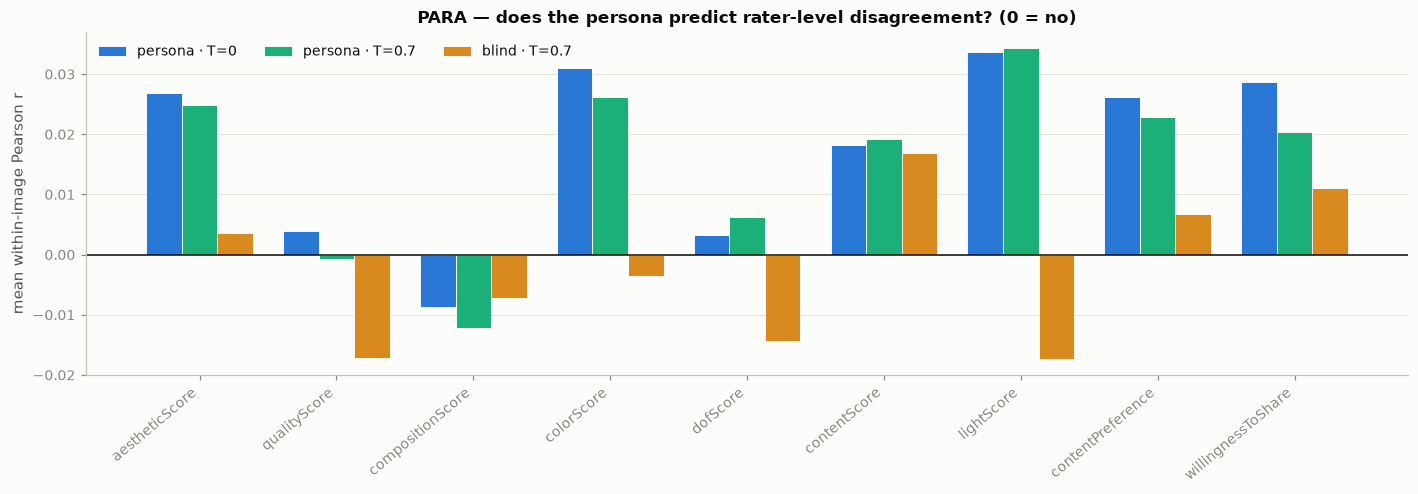

mean_within_r  frac_pred_varies  images_scored  images
axis               condition                                                              
aestheticScore     blind · T=0.7            0.004             0.117            234    2000
                   persona · T=0            0.027             0.517           1034    2000
                   persona · T=0.7          0.025             0.578           2313    4000
colorScore         blind · T=0.7           -0.004             0.133            266    2000
                   persona · T=0            0.031             0.478            957    2000
                   persona · T=0.7          0.026             0.504           2017    4000
compositionScore   blind · T=0.7           -0.007             0.107            215    2000
                   persona · T=0           -0.009             0.385            770    2000
                   persona · T=0.7         -0.012             0.390           1559    4000
contentPreference  blind · T=0.7            0.007             0.141            283    2000
                   persona · T=0            0.026             0.693           1386    2000
                   persona · T=0.7          0.023             0.683           2733    4000
contentScore       blind · T=0.7            0.017             0.136            272    2000
                   persona · T=0            0.018             0.568           1135    2000
                   persona · T=0.7          0.019             0.578           2310    4000
dofScore           blind · T=0.7           -0.014             0.135            270    2000
                   persona · T=0            0.003             0.548           1096    2000
                   persona · T=0.7          0.006             0.565           2259    4000
lightScore         blind · T=0.7           -0.017             0.147            295    2000
                   persona · T=0            0.034             0.445            890    2000
                   persona · T=0.7          0.034             0.483           1931    4000
qualityScore       blind · T=0.7           -0.017             0.205            350    2000
                   persona · T=0            0.004             0.620           1188    2000
                   persona · T=0.7         -0.001             0.648           2503    4000
willingnessToShare blind · T=0.7            0.011             0.168            336    2000
                   persona · T=0            0.029             0.720           1439    2000
                   persona · T=0.7          0.020             0.739           2954    4000

In [13]:
# Does conditioning on WHO is rating add signal? For each image, correlate the model's
# per-rater prediction with that rater's true score, then average over images. ~0 means the
# model gives essentially one answer per image regardless of the persona it was handed.
rows = []
for lbl, d in DATA.items():
    for dim in DIMS:
        w = within_image_corr(d["df"], dim)
        rows.append(dict(condition=lbl, axis=dim, mean_within_r=w["mean_r"],
                         frac_pred_varies=w["frac_pred_varies"],
                         images_scored=w["n_scored"], images=w["n_img"]))
within = pd.DataFrame(rows)

x = np.arange(len(DIMS)); w = 0.26
fig, ax = plt.subplots(figsize=(13, 4.6))
for i, lbl in enumerate(DATA):
    sub = within[within["condition"] == lbl].set_index("axis").reindex(DIMS)
    ax.bar(x + (i - 1) * w, sub["mean_within_r"], w, color=COND_COLOR[lbl], label=lbl,
           edgecolor=SURFACE, linewidth=0.6)
ax.axhline(0, color=INK, lw=1)
ax.set_xticks(x, DIMS, rotation=40, ha="right"); ax.xaxis.grid(False)
ax.set_ylabel("mean within-image Pearson r")
ax.set_title(f"{DATASET} — does the persona predict rater-level disagreement? (0 = no)")
ax.legend(ncol=3, loc="best"); fig.tight_layout(); plt.show()
within.set_index(["axis", "condition"]).sort_index()

## 5 · Do the axes collapse?

Cross-axis correlation of per-image mean predictions. Uniformly high r ⇒ the model is emitting one latent judgement dressed up as several axes.

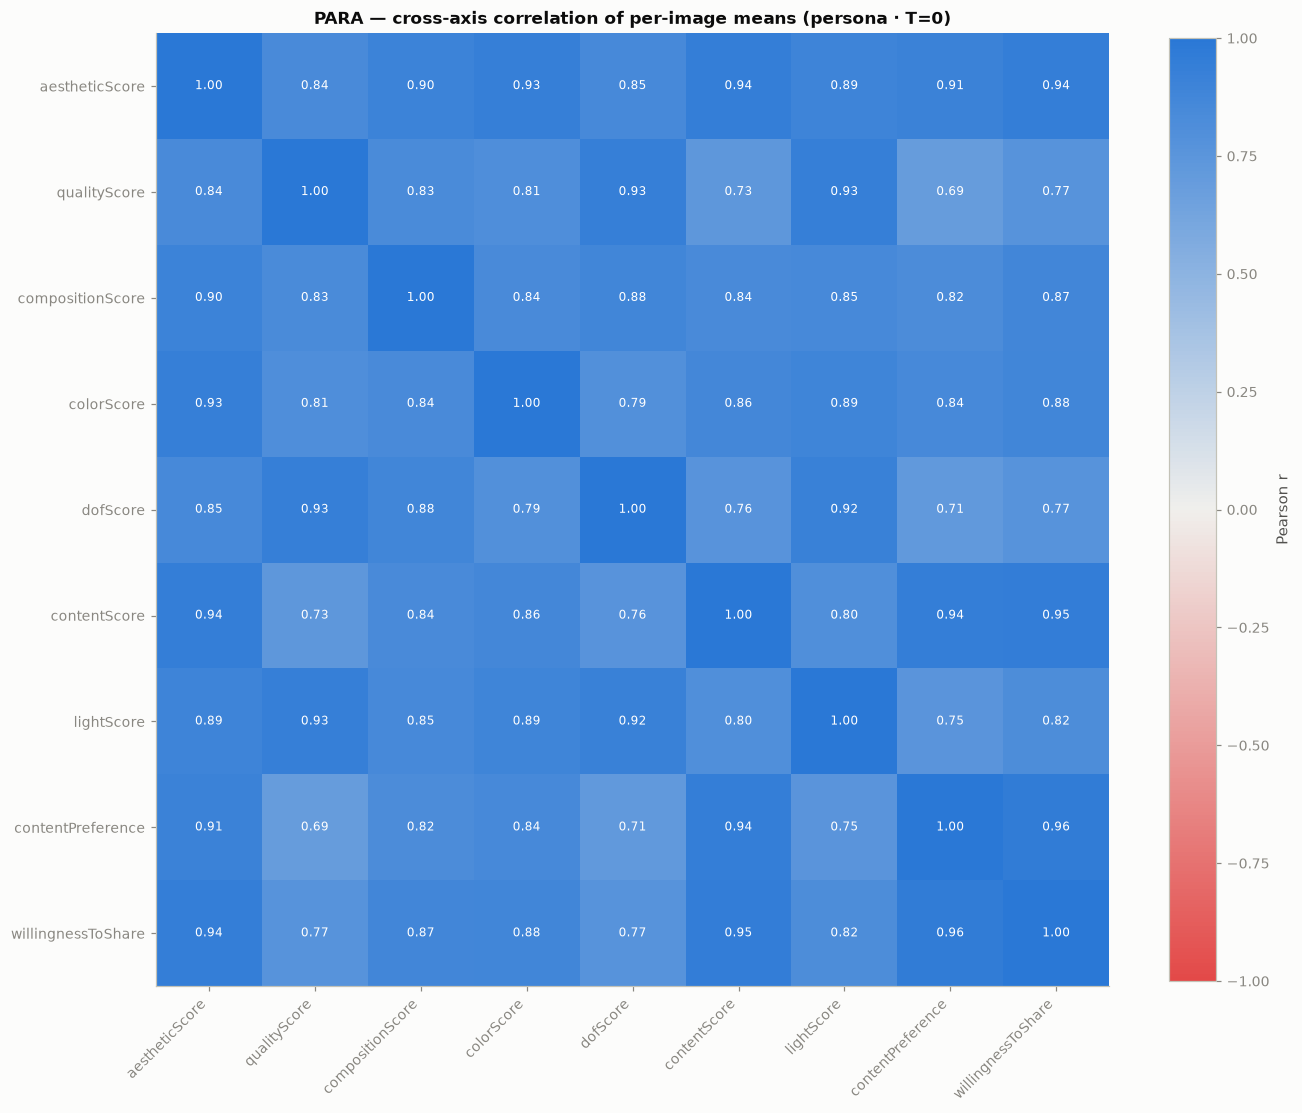

mean off-diagonal r: 0.852


In [14]:
# Do the axes measure different things, or collapse to one latent judgement?
# Pearson r between per-image MEAN predictions across axes (persona-T=0).
if len(DIMS) >= 2:
    d = DATA["persona · T=0"]
    means = pd.DataFrame({dim: pairs(d["df"], dim).groupby("imageName")["pred"].mean() for dim in DIMS})
    corr = means.corr()
    fig, ax = plt.subplots(figsize=(1.05 * len(DIMS) + 3, 1.0 * len(DIMS) + 2.5))
    im = ax.imshow(corr, cmap=CORR_CMAP, vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr)), corr.index)
    for a in range(len(corr)):
        for b in range(len(corr)):
            v = corr.iat[a, b]
            ax.annotate(f"{v:.2f}", (b, a), ha="center", va="center", fontsize=8,
                        color="#ffffff" if abs(v) > 0.62 else INK)
    ax.grid(False); ax.set_title(f"{DATASET} — cross-axis correlation of per-image means (persona · T=0)")
    fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
    fig.tight_layout(); plt.show()
    print("mean off-diagonal r:", round(corr.where(~np.eye(len(corr), dtype=bool)).stack().mean(), 3))
else:
    print(f"{DATASET} has a single axis ({DIMS[0]}) — no cross-axis structure to show.")

## Verdict

In [15]:
# Printed, data-driven summary (no hand-typed numbers).
def block(lbl):
    d = DATA[lbl]
    m = {dim: per_rating_metrics(d["df"], dim) for dim in DIMS}
    beat = [dim for dim in DIMS if m[dim]["mae"] < m[dim]["base_mae_image"]]
    wr = np.nanmean([within_image_corr(d["df"], dim)["mean_r"] for dim in DIMS])
    return dict(
        mean_mae_ratio=np.mean([m[dim]["mae"] / m[dim]["base_mae_image"] for dim in DIMS]),
        mean_pearson=np.nanmean([m[dim]["pearson"] for dim in DIMS]),
        axes_beating_image_baseline=f"{len(beat)}/{len(DIMS)}",
        mean_within_image_r=wr,
    )

print(f"===== {DATASET}: headline =====")
summary = pd.DataFrame({lbl: block(lbl) for lbl in DATA}).T
print(summary.to_string())
print("\nReadout:")
print(" - mean_mae_ratio > 1  => on average worse than just predicting each image's human mean.")
print(" - mean_pearson       => image-ordering signal (moderate is typical; that lives at image level).")
print(" - mean_within_image_r ~ 0 => persona conditioning barely predicts rater-to-rater disagreement.")

===== PARA: headline =====


/tmp/ipykernel_163841/1273685708.py:44: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = stats.pearsonr(g["pred"], g["gt"])[0]


/tmp/ipykernel_163841/1273685708.py:44: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = stats.pearsonr(g["pred"], g["gt"])[0]


/tmp/ipykernel_163841/1273685708.py:44: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = stats.pearsonr(g["pred"], g["gt"])[0]


                mean_mae_ratio mean_pearson axes_beating_image_baseline mean_within_image_r
persona · T=0            1.863        0.447                         0/9               0.018
persona · T=0.7          1.845        0.451                         0/9               0.016
blind · T=0.7            1.529        0.467                         0/9              -0.002

Readout:
 - mean_mae_ratio > 1  => on average worse than just predicting each image's human mean.
 - mean_pearson       => image-ordering signal (moderate is typical; that lives at image level).
 - mean_within_image_r ~ 0 => persona conditioning barely predicts rater-to-rater disagreement.


### Caveats to keep attached to these numbers
- Temperature was inert (greedy decoding); `T=0` and `T=0.7` differ only by image sample, so their gap is a reproducibility check, not a sampling effect.
- Blind EMD/KS/within-image spread are artefacts of the decoding collapse, not taste.
- Baselines (`base_mae_*`) are ground-truth-only oracles — they see the human means the model never does; clearing them is a high bar by design.
- MAE is on each axis's native scale; cross-axis comparisons use the scale-free views (Pearson r, MAE-vs-baseline ratio, standardised bias).